# Fase 3: Procesamiento de datos

**Carga de paquetes e instacias necesarias**.

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer, ColumnTransformer
from BorutaShap import BorutaShap

**Carga de los datos limpios**.

In [48]:
data = pd.read_csv("../data/processed/sacramento_cleaned.csv")
data.head()


,beds,baths,sqft,type,price,latitude,longitude
0,2,1.0,836,residential,59222,38.631913,-121.434879
1,3,1.0,1167,residential,68212,38.478902,-121.431028
2,2,1.0,796,residential,68880,38.618305,-121.443839
3,2,1.0,852,residential,69307,38.616835,-121.439146
4,2,1.0,797,residential,81900,38.519470,-121.435768


**Crear la discretización del precio de la vivienda**: Ayuda a eliminar el sesgo al realizar el split de los datos y a asegurar representatividad.

In [6]:
price_cuts = np.quantile(data["price"], [0.2, 0.4, 0.6, 0.8])
price_discretized = pd.cut(data["price"],
                           bins = [-np.inf, price_cuts[0], price_cuts[1],
                                   price_cuts[2], price_cuts[3], np.inf],
                           labels = [1, 2, 3, 4, 5])

**Generar el train-test split**: Realiza el split de los datos considerando un muestreo estratificado para asegurar representatividad del target tanto en el training como en el test set.

In [7]:
train, test = train_test_split(data, test_size = 0.3,
                               stratify = price_discretized,
                               random_state = 42)

**Separación de variables independientes (predictores)**: Se elimina la variable objetivo para aislar las características que alimentarán el modelo.

In [8]:
X_train = train.drop(columns = ["price"])
X_train.head()

,beds,baths,sqft,type,latitude,longitude,baths_per_sqft,beds_per_sqft,sqft_log
234,3,2.0,1665,Residential,38.631026,-121.501879,0.001201,0.001802,7.418181
485,4,4.0,1995,Multi_Family,38.490704,-121.410176,0.002005,0.002005,7.598900
307,3,2.0,1665,Residential,38.668692,-121.545490,0.001201,0.001802,7.418181
314,3,2.0,1119,Residential,38.476472,-121.501711,0.001787,0.002681,7.021084
321,2,1.0,924,Condo,38.658739,-121.333561,0.001082,0.002165,6.829794


**Aislamiento de la variable objetivo**: Se crea un vector independiente para los targets de entrenamiento.

In [9]:
y_train = train["price"].copy()

**Configuración del imputador de valores faltantes**: Se inicializa una estrategia de imputación basada en la mediana para manejar datos nulos en variables numéricas.

In [10]:
imputer = SimpleImputer(strategy = "median")

**Segregación de tipos de datos**: División del conjunto de entrenamiento en subconjuntos numéricos y categóricos para aplicar tratamientos diferenciados.

In [11]:
X_train_num = X_train.select_dtypes(include = np.number)
X_train_cat = X_train.select_dtypes(exclude = np.number)
X_train_num.head()
X_train_cat.head()

,type
234,Residential
485,Multi_Family
307,Residential
314,Residential
321,Condo


**Entrenamiento del imputador**: Ajuste del `SimpleImputer` utilizando exclusivamente el conjunto de datos numéricos.

In [12]:
imputer = imputer.fit(X_train_num)

**Inspección de parámetros aprendidos**: Verificación de los valores de mediana calculados por el imputador para cada columna.

In [13]:
imputer.statistics_

array([ 3.00000000e+00,  2.00000000e+00,  1.47700000e+03,  3.86219980e+01,
       -1.21377471e+02,  1.26742712e-03,  2.10231254e-03,  7.29844510e+00])

**Validación cruzada de estadísticas**: Comprobación manual de las medianas del DataFrame original para asegurar consistencia con el imputador.

In [14]:
X_train_num.median()

beds                 3.000000
baths                2.000000
sqft              1477.000000
latitude            38.621998
longitude         -121.377471
baths_per_sqft       0.001267
beds_per_sqft        0.002102
sqft_log             7.298445
dtype: float64

**Prueba rápida de codificación**: Evaluación del impacto de una codificación one-hot mediante `pandas` (uso exploratorio).

In [15]:
pd.get_dummies(X_train_cat, dtype = "int")

,type_Condo,type_Multi_Family,type_Residential
234,0,0,1
485,0,1,0
307,0,0,1
314,0,0,1
321,1,0,0
...,...,...,...
610,0,0,1
412,0,0,1
123,0,0,1
273,0,0,1


**Inicialización del codificador categórico**: Configuración de `OneHotEncoder` de `scikit-learn` para convertir variables cualitativas en representaciones numéricas.

In [16]:
encoder = OneHotEncoder(sparse_output = False)

**Transformación de variables categóricas**: Aplicación del fit-transform para generar la matriz de variables dummy.

In [17]:
X_train_cat_1hot = encoder.fit_transform(X_train_cat)

**Extracción de metadatos de categorías**: Recuperación de las categorías únicas identificadas durante el ajuste del codificador.

In [18]:
categories = encoder.categories_

**Configuración de estandarización**: Inicialización de `StandardScaler` para reescalar las variables numéricas a una distribución con media 0 y desviación estándar 1.

In [19]:
scaler = StandardScaler()

**Aplicación de la estandarización**: Uso de `fit_transform` para realizar la estandarización de datos.

In [20]:
X_train_num_std = scaler.fit_transform(X_train_num)

**Definición de transformación logarítmica**: Creación de un transformador personalizado para reducir el sesgo en variables con distribuciones de cola larga.

In [21]:
log_transformer = FunctionTransformer(func = np.log, inverse_func = np.exp)

**Ingeniería de variables (log-transform)**: Aplicación de logaritmo a la variable de pies cuadrados para normalizar su distribución.

In [22]:
log_sqft = log_transformer.fit_transform(X_train["sqft"])

**Lógica para creación de ratios**: Función personalizada que calcula el cociente entre dos columnas de una matriz.

In [23]:
def column_ratio(X):
    '''
    Realiza el cociente entre la primera y segunda columna de un arreglo.
    '''

    return X[:, [0]]/X[:, [1]]

**Transformador funcional para ratios**: Encapsulamiento de la función de cociente en un `FunctionTransformer` compatible con `scikit-learn`.

In [24]:
ratio_transf = FunctionTransformer(column_ratio)

**Ingeniería de variables (Baths/Sqft)**: Generación de una nueva métrica que representa el número de baños proporcional al tamaño de la vivienda.

In [25]:
baths_per_sqft = ratio_transf.fit_transform(X_train[["baths", "sqft"]].to_numpy())

**Ingeniería de variables (Beds/Sqft)**: Generación de una métrica que representa la densidad de habitaciones por pie cuadrado.

In [26]:
beds_per_sqft = ratio_transf.fit_transform(X_train[["beds", "sqft"]].to_numpy())

**Construcción del pipeline numérico**: Encadenamiento secuencial de la imputación de valores nulos y el escalamiento de datos.

In [27]:
num_pipeline = make_pipeline(SimpleImputer(strategy = "median"), StandardScaler())

**Procesamiento integral de datos numéricos**: Ejecución del pipeline completo sobre todas las columnas numéricas.

In [28]:
X_train_num_prepared = num_pipeline.fit_transform(X_train_num)

**Reconstrucción de estructura tabular**: Conversión de la matriz resultante del pipeline numérico de vuelta a un data frame de `pandas` con nombres de columnas originales.

In [29]:
num_data_prepared = pd.DataFrame(X_train_num_prepared,
                                 columns = num_pipeline.get_feature_names_out(),
                                 index = X_train_num.index)

**Construcción del pipeline categórico**: Configuración de imputación por moda seguido de codificación one-hot de modo que si la pipeline observa una categoría que no se encuentre en el training set la ignorará, así toda esa observación se mapeará a un vector de ceros.

In [30]:
cat_pipeline = make_pipeline(SimpleImputer(strategy = "most_frequent"),
                             OneHotEncoder(handle_unknown = "ignore"))

**Procesamiento integral de datos categóricos**: Ejecución del pipeline de limpieza y codificación para variables cualitativas.

In [31]:
X_train_cat_prepared = cat_pipeline.fit_transform(X_train_cat)

**Definición del transformador de columnas global**: Integración de los pipelines numérico y categórico mediante selectores automáticos de tipo de dato.

In [32]:
preprocessing = make_column_transformer((num_pipeline,
                                         make_column_selector(dtype_include = np.number)),
                                        (cat_pipeline,
                                         make_column_selector(dtype_exclude = np.number)))

**Ejecución del preprocesamiento base**: Transformación completa del dataset original aplicando todas las reglas definidas anteriormente.

In [33]:
X_train_prepared = preprocessing.fit_transform(X_train)

**Utilidad para nombrado de columnas**: Función para asignar nombres consistentes a las nuevas variables de ratio generadas en el pipeline.

In [34]:
def ratio_name(function_transformer, feature_names_in):
    '''
    Regresa el nombre de las variables de entrada con el sufijo "ratio".
    '''

    return ["ratio"]

**Pipeline para ratios**: Función que encapsula el flujo completo para nuevas variables (Imputación -> Ratio -> Estandarización).

In [35]:
def ratio_pipeline():
    pipeline = make_pipeline(SimpleImputer(strategy = "median"),
                             FunctionTransformer(column_ratio,
                                                 feature_names_out = ratio_name),
                             StandardScaler())
    return pipeline

**Pipeline avanzado para transformaciones logarítmicas**: Flujo que imputa, aplica logaritmo (con soporte para nombres de columnas) y estandariza.

In [36]:
log_pipeline = make_pipeline(SimpleImputer(strategy = "median"),
                             FunctionTransformer(np.log, np.exp,
                                         feature_names_out = "one-to-one"),
                             StandardScaler())

**Pipeline numérico por defecto**: Configuración estándar de limpieza y estandarización para variables sin transformaciones especiales.

In [37]:
default_num_pipeline = make_pipeline(SimpleImputer(strategy = "median"),
                                     StandardScaler())

**Configuración final de preprocesamiento (Producción)**: Orquestación que aplica diferentes pipelines según la columna específica: ratios de baños/camas, escala logarítmica para área, codificación para categorías y procesamiento estándar para el resto.

In [38]:
preprocessing = ColumnTransformer([("default", default_num_pipeline, ["baths", "beds"]),
                                   ("baths", ratio_pipeline(), ["baths", "sqft"]),
                                   ("beds", ratio_pipeline(), ["beds", "sqft"]),
                                   ("log", log_pipeline, ["sqft"]),
                                   ("cat", cat_pipeline,
                                    make_column_selector(dtype_exclude = np.number))],
                                   remainder = default_num_pipeline)

**Ejecución del preprocesamiento final**: Transformación definitiva de los datos de entrenamiento para la fase de modelado.

In [39]:
X_train_prepared = preprocessing.fit_transform(X_train)

**Inicialización del selector de características**: Configuración de BorutaSHAP utilizando valores SHAP para un problema de regresión.

In [40]:
feature_selector = BorutaShap(importance_measure = "shap", classification = False)

**Preparación de datos para selección**: Reconstrucción del data frame final con nombres de columnas obtenidos del objeto `preprocessing` para facilitar la interpretación del selector.

In [41]:
X_train_prepared = pd.DataFrame(X_train_prepared,
                                 columns = preprocessing.get_feature_names_out(),
                                 index = X_train_num.index)

**Ejecución del algoritmo Boruta**: Proceso de selección de variables mediante comparaciones con variables shadow en 100 iteraciones.

In [42]:
feature_selector.fit(X = X_train_prepared, y = y_train, n_trials = 100)

  0%|          | 0/100 [00:00<?, ?it/s]

7 attributes confirmed important: ['baths__ratio', 'remainder__latitude', 'remainder__longitude', 'log__sqft', 'remainder__sqft_log', 'beds__ratio', 'remainder__beds_per_sqft']
6 attributes confirmed unimportant: ['cat__type_Condo', 'cat__type_Residential', 'default__beds', 'default__baths', 'cat__type_Multi_Family', 'remainder__baths_per_sqft']
0 tentative attributes remains: []


**Visualización de importancia de variables**: Gráfico de las características aceptadas, rechazadas y dudosas según su impacto en el modelo.

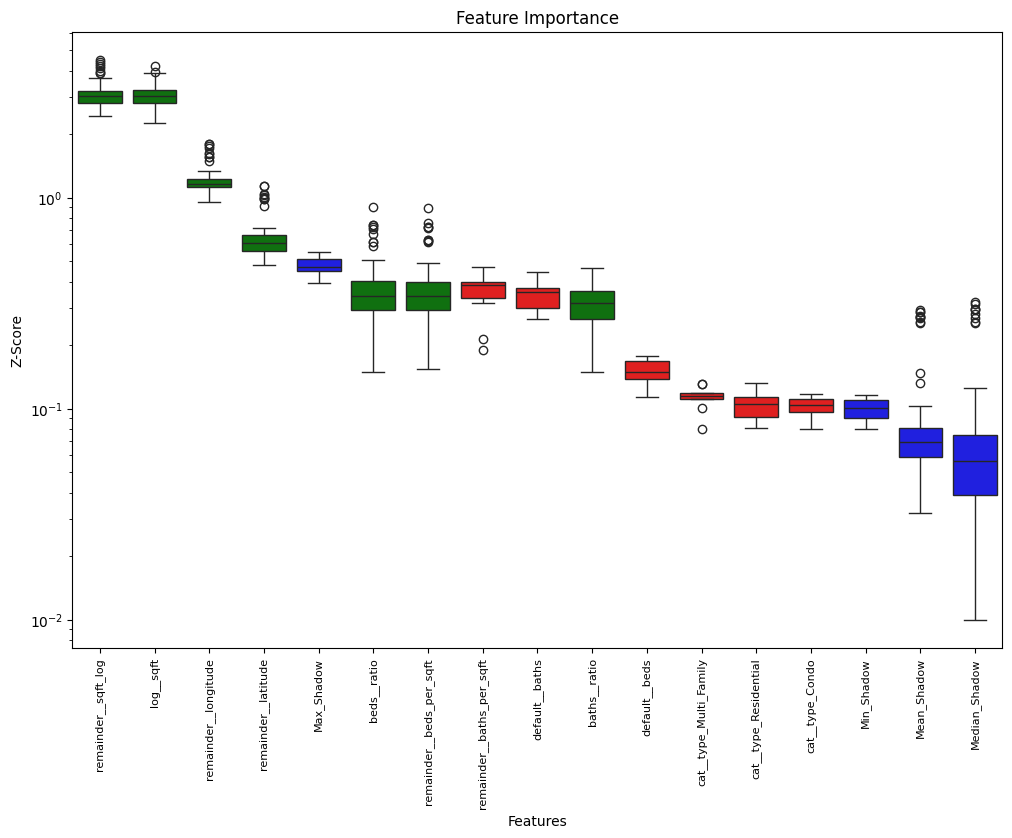

In [43]:
feature_selector.plot(which_features = "all")

**Extracción del conjunto óptimo**: Obtención del data frame final que contiene únicamente las variables seleccionadas como predictoras significativas.

In [44]:
X_train_subset = feature_selector.Subset()

**Guardar el resultado en formato `.csv` en la carpeta correspondiente**.

In [45]:
df_train = X_train_subset.copy()
df_train["price"] = y_train
df_train.to_csv("../data/processed/sacramento_train.csv", index = False)

**Correr la pipeline para el test set**: Asegurar que se corre la transformación solamente.

In [46]:
X_test = test.drop(columns = ["price"])
y_test = test["price"].copy()
X_test_prepared = preprocessing.transform(X_test)

**Extraer las variables seleccionadas de BorutaSHAP**: Se realiza la misma extracción de features para el test set.

In [47]:
X_test_prepared = pd.DataFrame(X_test_prepared,
                                 columns = preprocessing.get_feature_names_out(),
                                 index = X_test.index)
X_test_prepared[X_train_subset.columns]

,baths__ratio,remainder__latitude,remainder__longitude,log__sqft,remainder__sqft_log,beds__ratio,remainder__beds_per_sqft
523,-0.933714,1.104991,0.735089,0.740555,0.740492,-1.225765,-1.225765
268,0.091664,0.394144,-0.687916,-0.062525,-0.062647,-0.244101,-0.244101
433,-0.946120,-0.387122,-0.115951,-1.052077,-1.052038,1.466299,1.466299
8,1.823861,-1.321134,-0.630107,-1.026906,-1.026874,-0.371027,-0.371027
55,0.063640,-1.513961,-0.183986,-0.043571,-0.043693,-0.270929,-0.270929
...,...,...,...,...,...,...,...
152,-0.155724,-0.489867,-0.875154,-1.694270,-1.693938,0.672605,0.672605
396,0.135788,-0.713617,-0.710692,-0.092091,-0.092212,-0.201858,-0.201858
378,-0.381250,-1.150784,-0.609258,0.277438,0.277323,0.384723,0.384723
98,-0.562682,-1.045448,-0.520487,-1.383407,-1.383238,0.153127,0.153127
